In [1]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('default')
sns.set_palette("husl")
print("Setup complete!")

Setup complete!


# Nigeria (Lagos) - Climate Data Analysis

**Station:** Lagos | **Elevation:** Sea level | **Period:** 2015-2026

Lagos is a coastal megacity on the Gulf of Guinea (Atlantic Ocean). Its 
tropical climate features warm temperatures year-round, high humidity, 
and distinct wet and dry seasons driven by the West African Monsoon.

In [2]:
df = pd.read_csv('../data/nigeria.csv')
df['Country'] = 'Nigeria'
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df.replace(-999, np.nan, inplace=True)

print(f"Shape: {df.shape}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
df.head()

Shape: (4108, 16)
Date range: 2015-01-01 to 2026-03-31


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month,Year
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36,Nigeria,2015-01-01,1,2015
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37,Nigeria,2015-01-02,1,2015
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98,Nigeria,2015-01-03,1,2015
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,Nigeria,2015-01-04,1,2015
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,Nigeria,2015-01-05,1,2015


In [3]:
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100
print("Missing values (>0%):")
print(missing_pct[missing_pct > 0])
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values (>0%):
Series([], dtype: float64)

Duplicate rows: 0


In [4]:
df_clean = df.copy()
weather_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 
                'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']
df_clean[weather_cols] = df_clean[weather_cols].ffill()
df_clean.to_csv('../data/nigeria_clean.csv', index=False)
print("Cleaned data saved!")


Cleaned data saved!


In [5]:
print("NIGERIA TEMPERATURE SUMMARY")
print(f"Mean T2M: {df_clean['T2M'].mean():.1f} C")
print(f"Max T2M: {df_clean['T2M'].max():.1f} C")
print(f"Min T2M: {df_clean['T2M'].min():.1f} C")
print(f"Std Dev: {df_clean['T2M'].std():.1f} C")
print(f"Mean Daily Range: {df_clean['T2M_RANGE'].mean():.1f} C")

heat_days = (df_clean['T2M_MAX'] > 35).sum()
heat_days_40 = (df_clean['T2M_MAX'] > 40).sum()
print(f"Days T2M_MAX > 35C: {heat_days} ({heat_days/len(df_clean)*100:.1f}%)")
print(f"Days T2M_MAX > 40C: {heat_days_40}")

NIGERIA TEMPERATURE SUMMARY
Mean T2M: 26.7 C
Max T2M: 29.3 C
Min T2M: 21.1 C
Std Dev: 1.1 C
Mean Daily Range: 4.0 C
Days T2M_MAX > 35C: 0 (0.0%)
Days T2M_MAX > 40C: 0


In [7]:
# Outlier Detection using Z-score
print("OUTLIER DETECTION (|Z| > 3):")
outlier_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
for col in outlier_cols:
    if col in df_clean.columns:
        z_scores = np.abs(stats.zscore(df_clean[col].dropna()))
        outliers = (z_scores > 3).sum()
        print(f"  {col}: {outliers} outliers ({(outliers/len(df_clean))*100:.1f}%)")

OUTLIER DETECTION (|Z| > 3):
  T2M: 10 outliers (0.2%)
  T2M_MAX: 1 outliers (0.0%)
  T2M_MIN: 68 outliers (1.7%)
  PRECTOTCORR: 75 outliers (1.8%)
  RH2M: 128 outliers (3.1%)
  WS2M: 5 outliers (0.1%)
  WS2M_MAX: 10 outliers (0.2%)


**Outlier Detection Results:**

The Z-score analysis (|Z| > 3) identified the following outliers:
- T2M: 10 outliers (0.2%) - Negligible, retained
- T2M_MAX: 1 outlier (0.0%) - Negligible, retained
- T2M_MIN: 68 outliers (1.7%) - These likely represent Harmattan season cold
  spells when dry desert air drops nighttime temperatures. Retained as valid
  climate phenomena
- PRECTOTCORR: 75 outliers (1.8%) - Extreme rainfall events (up to 166.10 mm/day)
  critical for flood analysis. Retained
- RH2M: 128 outliers (3.1%) - Higher humidity variability reflects Lagos' coastal
  location and seasonal monsoon influence. Retained as valid climate signal
- WS2M: 5 outliers (0.1%) - Negligible, retained
- WS2M_MAX: 10 outliers (0.2%) - Minor, retained

**Decision:** All outliers were retained. Nigeria's higher outlier counts for
T2M_MIN (1.7%) and RH2M (3.1%) reflect real coastal and seasonal climate dynamics
rather than data errors. The precipitation extremes are essential for understanding
Lagos' flood vulnerability.

**Temperature Observations:**

Lagos has a hot tropical climate with consistently warm temperatures year-round. 
The low diurnal temperature range reflects the moderating influence of the 
Atlantic Ocean and high humidity levels. Unlike continental locations, coastal 
Lagos experiences minimal seasonal temperature variation.

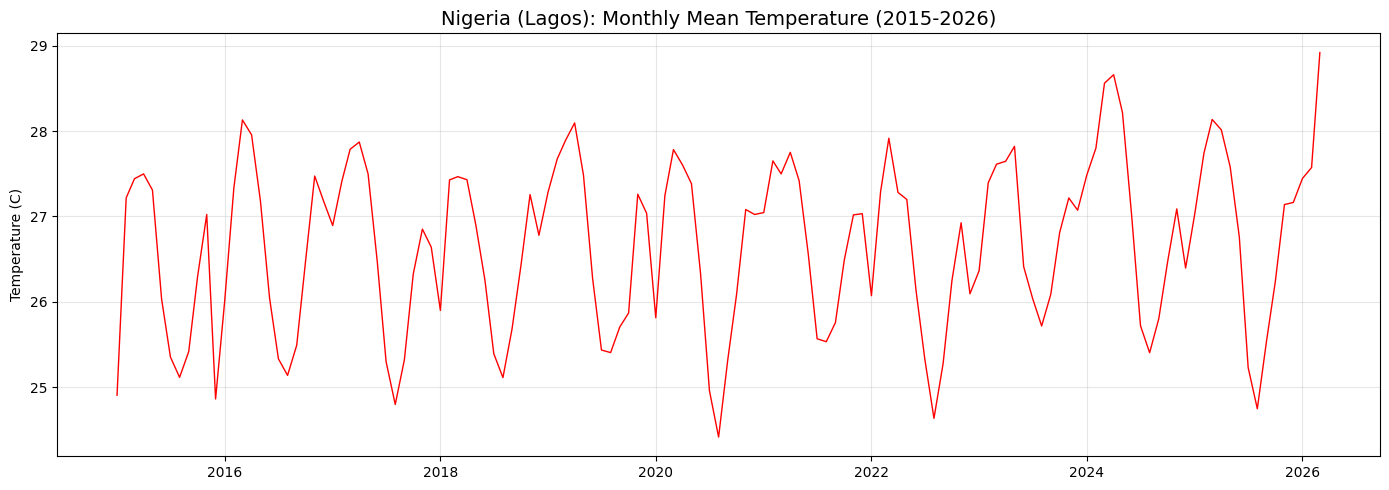

In [9]:
monthly_temp = df_clean.groupby(['Year', 'Month'])['T2M'].mean().reset_index()
monthly_temp['Date'] = pd.to_datetime(monthly_temp[['Year', 'Month']].assign(Day=1))

plt.figure(figsize=(14, 5))
plt.plot(monthly_temp['Date'], monthly_temp['T2M'], 'r-', linewidth=1)
plt.title('Nigeria (Lagos): Monthly Mean Temperature (2015-2026)', fontsize=14)
plt.ylabel('Temperature (C)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Precipitation Analysis

In [10]:
print("NIGERIA PRECIPITATION SUMMARY")
print(f"Mean daily precip: {df_clean['PRECTOTCORR'].mean():.2f} mm")
print(f"Max daily precip: {df_clean['PRECTOTCORR'].max():.2f} mm")
print(f"Days with rain: {(df_clean['PRECTOTCORR'] > 0).sum()} ({(df_clean['PRECTOTCORR'] > 0).sum()/len(df_clean)*100:.0f}%)")
print(f"Days with no rain: {(df_clean['PRECTOTCORR'] == 0).sum()} ({(df_clean['PRECTOTCORR'] == 0).sum()/len(df_clean)*100:.0f}%)")

NIGERIA PRECIPITATION SUMMARY
Mean daily precip: 4.21 mm
Max daily precip: 166.10 mm
Days with rain: 3624 (88%)
Days with no rain: 484 (12%)


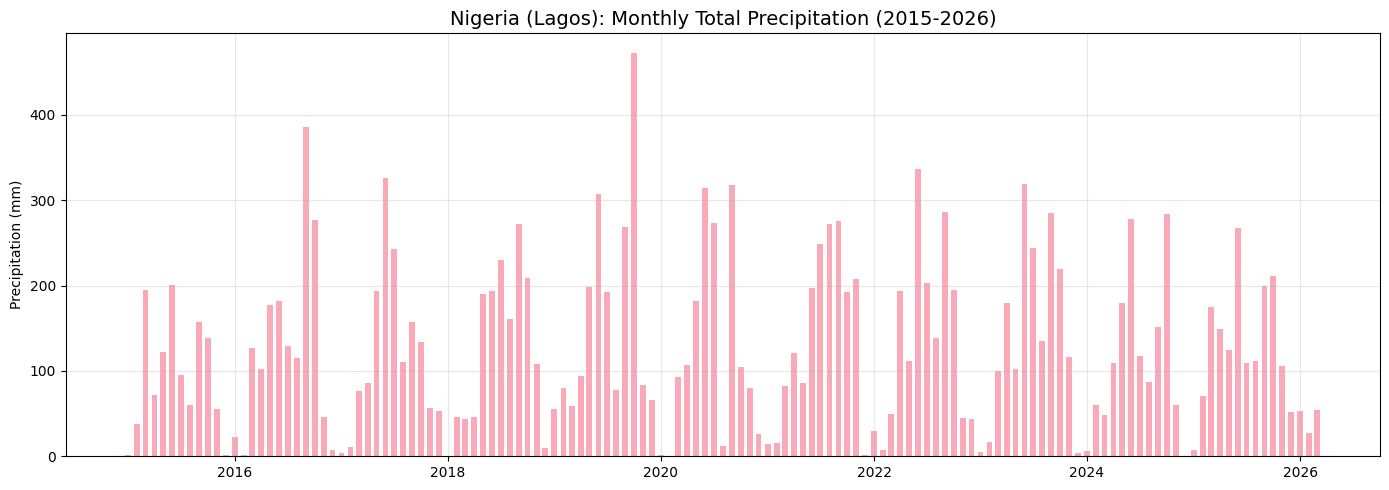

In [11]:
monthly_p = df_clean.groupby(['Year', 'Month'])['PRECTOTCORR'].sum().reset_index()
monthly_p['Date'] = pd.to_datetime(monthly_p[['Year', 'Month']].assign(Day=1))

plt.figure(figsize=(14, 5))
plt.bar(monthly_p['Date'], monthly_p['PRECTOTCORR'], width=20, alpha=0.6)
plt.title('Nigeria (Lagos): Monthly Total Precipitation (2015-2026)', fontsize=14)
plt.ylabel('Precipitation (mm)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
monthly_avg = df_clean.groupby('Month')['PRECTOTCORR'].mean()
print("Monthly average precipitation (mm/day):")
for m in range(1, 13):
    bars = '|' * int(monthly_avg[m] * 2)
    print(f"  Month {m:2d}: {monthly_avg[m]:5.2f}  {bars}")

Monthly average precipitation (mm/day):
  Month  1:  0.54  |
  Month  2:  1.10  ||
  Month  3:  2.96  |||||
  Month  4:  3.82  |||||||
  Month  5:  4.89  |||||||||
  Month  6:  8.85  |||||||||||||||||
  Month  7:  6.11  ||||||||||||
  Month  8:  3.75  |||||||
  Month  9:  8.35  ||||||||||||||||
  Month 10:  7.14  ||||||||||||||
  Month 11:  2.92  |||||
  Month 12:  0.78  |


**Precipitation Observations:**

Lagos experiences a tropical wet and dry climate with a pronounced rainy season 
driven by the West African Monsoon (approximately April to October) and a distinct 
dry season (November to March). The coastal location exposes Lagos to intense 
rainfall events that can cause urban flooding in this densely populated megacity 
of over 15 million residents.

## 3. Seasonal Climatology

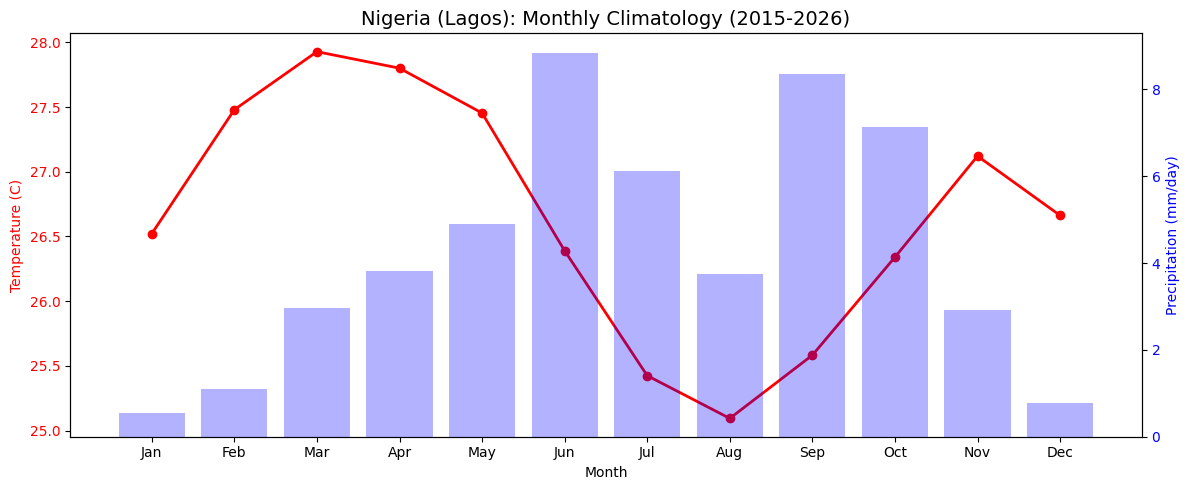

In [13]:
seasonal = df_clean.groupby('Month')[['T2M', 'PRECTOTCORR']].mean()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(seasonal.index, seasonal['T2M'], 'r-o', linewidth=2)
ax1.set_xlabel('Month')
ax1.set_ylabel('Temperature (C)', color='red')
ax1.tick_params(axis='y', labelcolor='red')

ax2 = ax1.twinx()
ax2.bar(seasonal.index, seasonal['PRECTOTCORR'], alpha=0.3, color='blue')
ax2.set_ylabel('Precipitation (mm/day)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title('Nigeria (Lagos): Monthly Climatology (2015-2026)', fontsize=14)
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.show()

## 4. Correlation Analysis

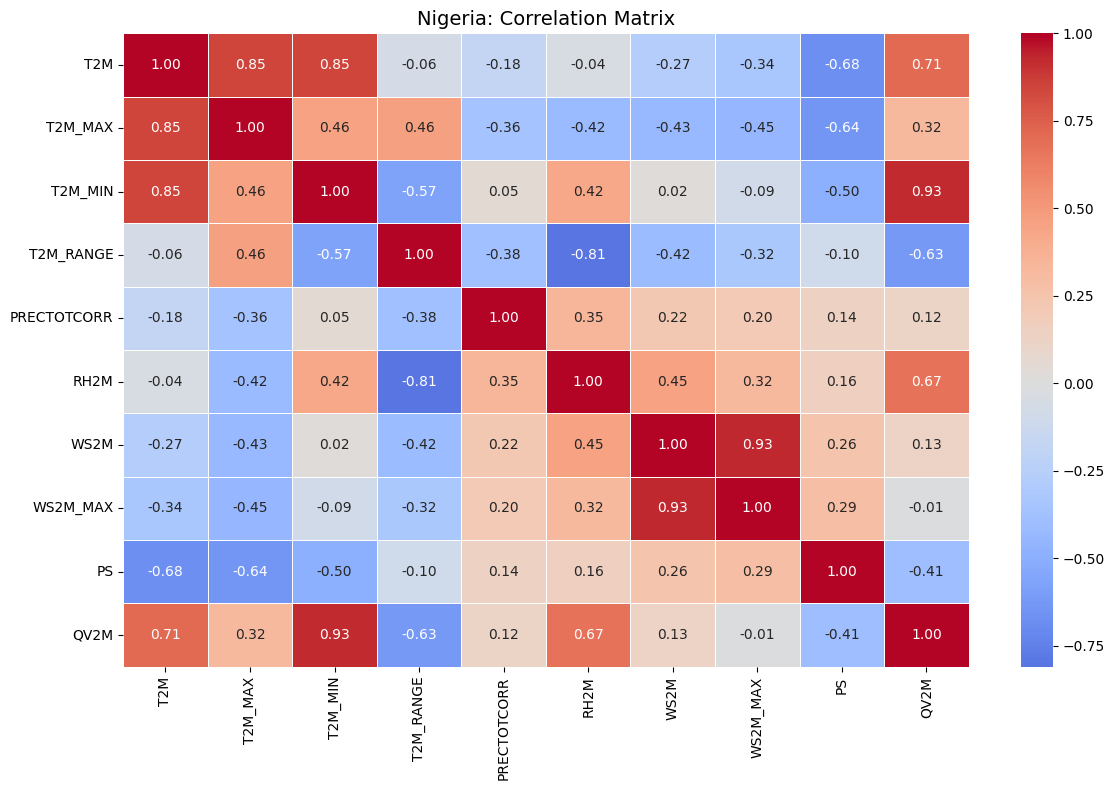

In [14]:
numeric_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 
                'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']
corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Nigeria: Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

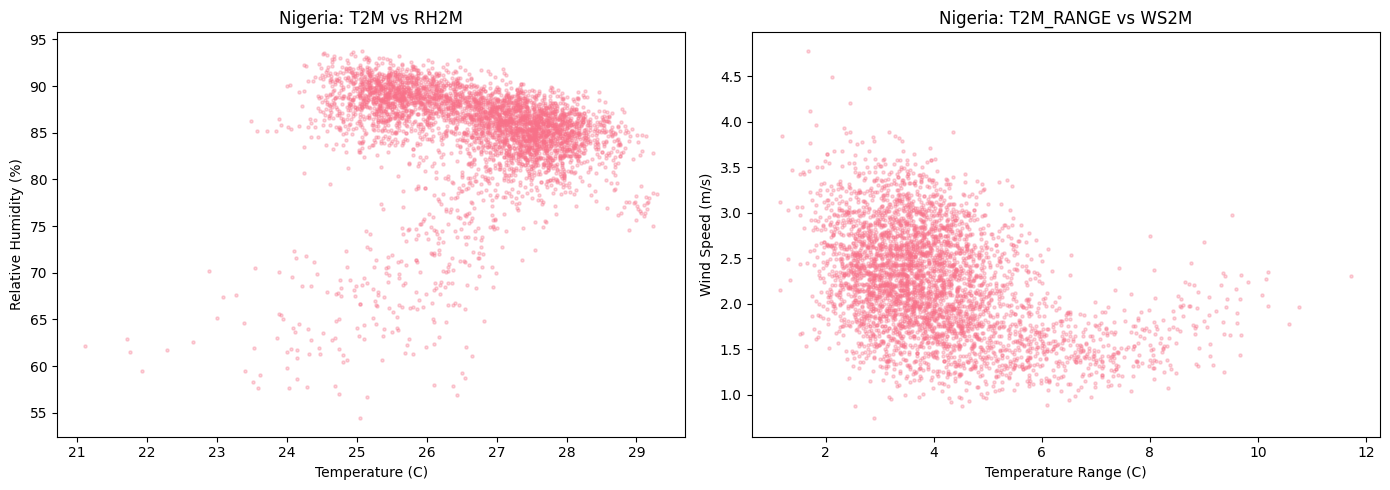

In [15]:
# Scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_clean['T2M'], df_clean['RH2M'], alpha=0.3, s=5)
axes[0].set_xlabel('Temperature (C)')
axes[0].set_ylabel('Relative Humidity (%)')
axes[0].set_title('Nigeria: T2M vs RH2M')

axes[1].scatter(df_clean['T2M_RANGE'], df_clean['WS2M'], alpha=0.3, s=5)
axes[1].set_xlabel('Temperature Range (C)')
axes[1].set_ylabel('Wind Speed (m/s)')
axes[1].set_title('Nigeria: T2M_RANGE vs WS2M')

plt.tight_layout()
plt.show()

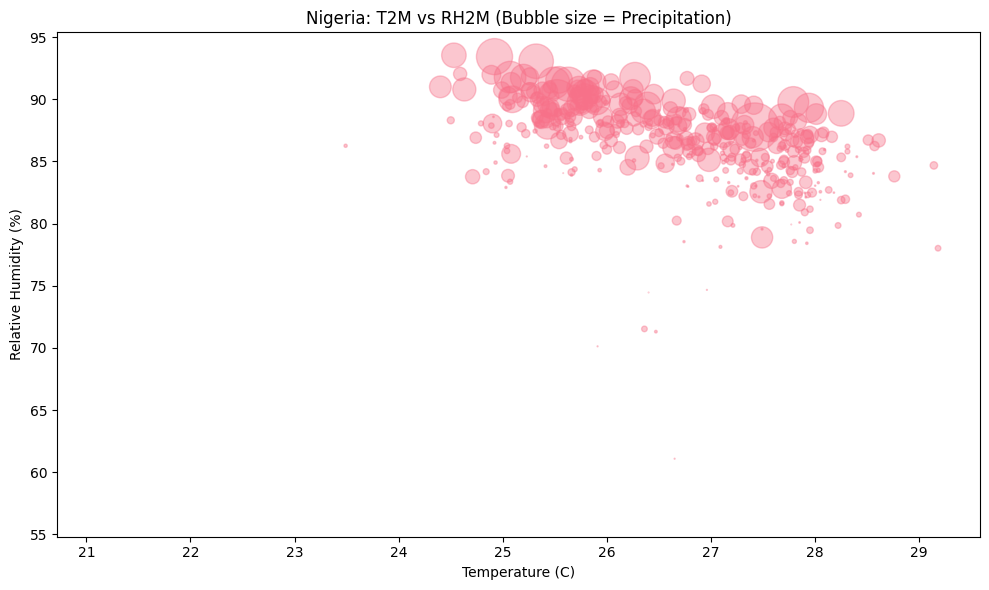

In [16]:
# Bubble chart: T2M vs RH2M, bubble size = precipitation
sample = df_clean.sample(min(500, len(df_clean)), random_state=42)
plt.figure(figsize=(10, 6))
plt.scatter(sample['T2M'], sample['RH2M'], s=sample['PRECTOTCORR']*20, alpha=0.4)
plt.xlabel('Temperature (C)')
plt.ylabel('Relative Humidity (%)')
plt.title('Nigeria: T2M vs RH2M (Bubble size = Precipitation)')
plt.tight_layout()
plt.show()

## 5. Precipitation Distribution

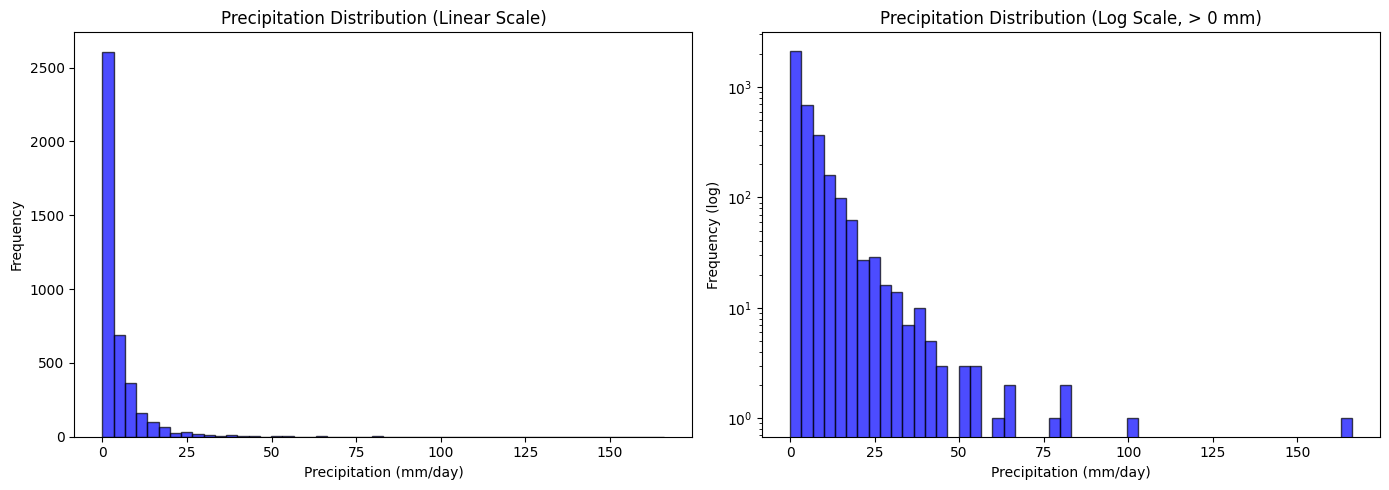

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean['PRECTOTCORR'], bins=50, color='blue', alpha=0.7, edgecolor='black')
axes[0].set_title('Precipitation Distribution (Linear Scale)')
axes[0].set_xlabel('Precipitation (mm/day)')
axes[0].set_ylabel('Frequency')

precip_positive = df_clean['PRECTOTCORR'][df_clean['PRECTOTCORR'] > 0]
axes[1].hist(precip_positive, bins=50, color='blue', alpha=0.7, edgecolor='black', log=True)
axes[1].set_title('Precipitation Distribution (Log Scale, > 0 mm)')
axes[1].set_xlabel('Precipitation (mm/day)')
axes[1].set_ylabel('Frequency (log)')

plt.tight_layout()
plt.show()

In [18]:
# Compare Nigeria with coastal Tanzania
df_tz = pd.read_csv('../data/tanzania_clean.csv')

print("=" * 50)
print("NIGERIA vs TANZANIA - COASTAL COMPARISON")
print("=" * 50)
print(f"{'Metric':<25} {'Nigeria':<12} {'Tanzania':<12}")
print("-" * 50)
print(f"{'Mean Temperature':<25} {df_clean['T2M'].mean():.1f} C{'':>6} {df_tz['T2M'].mean():.1f} C")
print(f"{'Max Temperature':<25} {df_clean['T2M'].max():.1f} C{'':>6} {df_tz['T2M'].max():.1f} C")
print(f"{'Min Temperature':<25} {df_clean['T2M'].min():.1f} C{'':>6} {df_tz['T2M'].min():.1f} C")
print(f"{'Mean Precip':<25} {df_clean['PRECTOTCORR'].mean():.2f} mm{'':>4} {df_tz['PRECTOTCORR'].mean():.2f} mm")
print(f"{'Max Precip':<25} {df_clean['PRECTOTCORR'].max():.1f} mm{'':>4} {df_tz['PRECTOTCORR'].max():.1f} mm")
print(f"{'Days with rain':<25} {(df_clean['PRECTOTCORR'] > 0).sum()} {'':>6} {(df_tz['PRECTOTCORR'] > 0).sum()}")

NIGERIA vs TANZANIA - COASTAL COMPARISON
Metric                    Nigeria      Tanzania    
--------------------------------------------------
Mean Temperature          26.7 C       26.8 C
Max Temperature           29.3 C       30.0 C
Min Temperature           21.1 C       22.7 C
Mean Precip               4.21 mm     3.74 mm
Max Precip                166.1 mm     122.7 mm
Days with rain            3624        3895


In [19]:
# ALL FIVE COUNTRIES SUMMARY
df_eth = pd.read_csv('../data/ethiopia_clean.csv')
df_ken = pd.read_csv('../data/kenya_clean.csv')
df_sud = pd.read_csv('../data/sudan_clean.csv')

print("=" * 60)
print("FIVE-COUNTRY CLIMATE SUMMARY")
print("=" * 60)
print(f"{'Country':<12} {'Elevation':<12} {'Mean T2M':<10} {'Precip':<10} {'Rain Days':<10} {'Heat Days':<10}")
print("-" * 60)
for name, df_c, elev in [('Sudan', df_sud, '~400m'), ('Nigeria', df_clean, 'Sea level'), 
                           ('Tanzania', df_tz, 'Sea level'), ('Kenya', df_ken, '~1,795m'), 
                           ('Ethiopia', df_eth, '~2,355m')]:
    heat = (df_c['T2M_MAX'] > 35).sum()
    rain = (df_c['PRECTOTCORR'] > 0).sum()
    print(f"{name:<12} {elev:<12} {df_c['T2M'].mean():.1f} C{'':>5} {df_c['PRECTOTCORR'].mean():.2f} mm{'':>4} {rain:<10} {heat:<10}")

FIVE-COUNTRY CLIMATE SUMMARY
Country      Elevation    Mean T2M   Precip     Rain Days  Heat Days 
------------------------------------------------------------
Sudan        ~400m        28.8 C      0.64 mm     1123       2694      
Nigeria      Sea level    26.7 C      4.21 mm     3624       0         
Tanzania     Sea level    26.8 C      3.74 mm     3895       0         
Kenya        ~1,795m      20.4 C      1.47 mm     3848       0         
Ethiopia     ~2,355m      16.1 C      3.63 mm     3256       0         


## Nigeria EDA Complete

Cleaned data saved to: data/nigeria_clean.csv

Nigeria (Lagos) represents the West African coastal climate: hot, humid, 
with a pronounced monsoon-driven rainy season. As a low-lying coastal megacity, 
Lagos faces compound risks from sea level rise, intense rainfall, and urban 
heat island effects. The extreme 166.10 mm daily rainfall record highlights 
the acute flood danger for this densely populated urban center of over 
15 million residents.